# CNN3D strawberry segmentation — reduced-budget reproduction (Le Louëdec & Cielniak, 2021)

Paper: **"3D shape sensing and deep learning-based segmentation of strawberries"**,
*Computers and Electronics in Agriculture* 190 (2021) 106374; [arXiv:2111.13663v1](https://arxiv.org/abs/2111.13663).
Author code: [lelouedec/PhD_3DPerception](https://github.com/lelouedec/PhD_3DPerception) @ `682e5d8` (no LICENSE file).

**Scope — PARTIAL, reduced-budget demonstration.** The paper trains CNN3D (a SegNet-style
encoder/decoder over organised 3D point grids, inputs = XYZ + surface normals) from
scratch on 134 simulated clouds and real stereo/ToF captures. **No trained weights are
published**, and the paper's *simulated* dataset (`Data_perfect`) is **not contained** in
the author's public data archive (verified in Colab: the archive holds the real
`Stereo/` and `Tof/` captures only). This notebook therefore:

1. downloads the author's real **stereo** captures (aligned depth + calibration + palette
   `label.png` annotations),
2. reconstructs organised 3D point grids + normals (adapted — see below),
3. trains the pinned author **CNN3D** on a small deterministic subset with the author's
   loss/optimizer (weighted cross-entropy `[1,16]`, Adam `lr=1e-5`), reduced to 40 epochs /
   batch 2 / 24 training clouds,
4. evaluates held-out clouds with the **author's exact metric code and threshold-sweep
   protocol** (`metrics.py`, `test.py` @ `682e5d8`), and compares against the paper's
   Table 4 stereo reference (Acc 92.11%, κ 0.62, mIoU 0.42, AUC 0.62) as *literature
   context only* — the reduced budget means results are **not** a reproduction of the
   published numbers.

This is **not** a full-paper reproduction; a single reduced run does not verify the
published dataset-level results.

**AI-assisted adaptation notice (EN):** the author's published loader
(`dataset_class.py`) targets the simulated data, which is not publicly available, and the
author's real-data preprocessing was not published. The real-data pipeline here (ROS-pickle
intrinsics parsing, 16-bit aligned-depth back-projection, organised-grid normal
estimation, resampling to the author's 871×530 grid) is an **AI-assisted adaptation**
validated end-to-end on one capture; author code is used verbatim for the model,
metrics, and evaluation protocol wherever possible.

**AI支援による翻訳/適応に関する注意（JA）：** 著者の公開ローダーは模擬データ用であり、
実データの前処理は未公開のため、本ノートブックの実データ処理はAI支援による適応です。
著者コードはモデル・評価指標・評価プロトコルにおいて可能な限りそのまま使用しています。

**実行環境（JA）：** GPU（T4）ランタイムが必要です。CPUでは学習を実行できません。

## 1. Runtime requirement and run instructions

**Select Runtime → Change runtime type → T4 GPU.** Training at the author's 871×871
padded resolution is VGG16-scale; the cell below hard-fails on a CPU runtime (no silent
fallback). Measured on a Colab T4 (2026-10-09): setup+download ≈ 5 min, training
(40 epochs × 12 steps) ≈ 25–35 min, evaluation+figures ≈ 3 min.

Expected downloads: the author's 486 MB Drive archive + a 528 MB VGG16 ImageNet
checkpoint (author's encoder initialisation).

**ランタイム（JA）：** 「ランタイム → ランタイムのタイプを変更 → T4 GPU」を選択してから
「ランタイム → すべてのセルを実行」してください。CPUでは学習不可です。

In [ ]:
import torch, sys
print("python:", sys.version.split()[0], "| torch:", torch.__version__)
if not torch.cuda.is_available():
    raise RuntimeError(
        "This reproduction requires a GPU (T4) Colab runtime: training the CNN3D at "
        "871x871 resolution is not practical on CPU. Select Runtime > Change runtime "
        "type > T4 GPU, then Run all. (GPU-required by the method; no silent CPU fallback.)")
device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0),
      "| total mem (GB):", round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1))

python: 3.13.15 | torch: 2.11.0+cu130
GPU: Tesla T4 | total mem (GB): 14.6


## 2. Dependencies

`torch`/`torchvision` are preinstalled on Colab. We add `gdown` (Google Drive download)
and `scipy` (the author's training-time augmentation uses `scipy.ndimage`). Nothing is
installed from the author repository itself; all author code is fetched pinned and
hash-verified in the next section.

**依存関係（JA）：** Colab標準のtorch/torchvisionに加え、gdownとscipyのみ追加します。

In [ ]:
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown", "scipy"],
                   capture_output=True, text=True)
print("pip returncode:", r.returncode)
if r.returncode != 0:
    print(r.stderr[-800:])
import gdown, scipy, numpy
print("gdown", gdown.__version__, "| scipy", scipy.__version__, "| numpy", numpy.__version__)

pip returncode: 0


gdown 5.2.2 | scipy 1.16.3 | numpy 2.1.3


## 3. Pinned author code retrieval and hash verification

The five files of `com_elec_agri/` are fetched from the pinned commit `682e5d8` and
verified against SHA-256 digests recorded from the same files via the trusted
code-only helper (`notes/port-source/INDEX.md`). `metrics.py` is imported **verbatim**
and used for all reported metrics. `CNN3D.py` and `dataset_class.py` are inspected but
**not imported** (see the labeled adaptations below); `train.py`/`test.py` define the
training/evaluation protocol followed in this notebook.

**著者コード（JA）：** ピン留めコミットから取得しSHA-256で検証します。metrics.pyは
そのまま import して使用します。

In [ ]:
import urllib.request, hashlib, pathlib, sys
COMMIT = "682e5d8fe8d3af29e540e18d7b0ab645233415e9"
BASE = f"https://raw.githubusercontent.com/lelouedec/PhD_3DPerception/{COMMIT}/com_elec_agri/"
DIGESTS = {  # sha256 recorded from the pinned tree on the host (notes/port-source/INDEX.md)
    "CNN3D.py": "6f9ac91b84ce04acd22bd525068bea65a66145149b14305465078dfb0b0d42ef",
    "dataset_class.py": "5510d8d80ad9a2830ab2bfec4e43b262738df7371ea99b9c5b686282f55d8553",
    "metrics.py": "41dc8ba930b00a79612316a0eb5d448742c71429610b6721c9aea06cad8cd9cc",
    "test.py": "63cc82068e536285a25ed41825fe45ff204519219b2ed965fca20bb3334bd57e",
    "train.py": "ef6951b230d8497654124c5ca4e6ea1d5132643c547b88c32c16ff5f42670f59",
}
dest = pathlib.Path("/content/author_code"); dest.mkdir(exist_ok=True)
for name, sha in DIGESTS.items():
    raw = urllib.request.urlopen(BASE + name, timeout=60).read()
    got = hashlib.sha256(raw).hexdigest()
    assert got == sha, f"{name}: sha256 mismatch {got}"
    (dest / name).write_bytes(raw)
    print(f"{name}: OK ({len(raw):,} bytes)")
sys.path.insert(0, str(dest))
import metrics  # author's verbatim metric functions (numpy only)
print("author metrics.py imported:", [f for f in dir(metrics) if not f.startswith('_')])

CNN3D.py: OK (9,212 bytes)
dataset_class.py: OK (4,527 bytes)


metrics.py: OK (3,286 bytes)
test.py: OK (3,547 bytes)


train.py: OK (2,092 bytes)
author metrics.py imported: ['Accuracy', 'IoU', 'Kappa_cohen', 'np', 'precision_recall']


## 4. Author-linked dataset archive (full download disclosed)

The author's README links one Drive archive for "Riseholme Farm pointclouds +
simulation". In Colab (2026-10-09) the archive was verified to be a 486 MB ZIP with a
single top-level `Segmentation_data/` folder containing real `Stereo/` (64 captures)
and `Tof/` (113 captures) — **no `.ply`/`.npy` and no simulated data**. We download the
full archive (disclosed) and extract only the required stereo files.

**データ（JA）：** 著者READMEのDriveアーカイブ（486 MB）を完全ダウンロードした上で、
必要なstereoキャプチャのファイルのみ展開します（模擬データは公開アーカイブに含まれません）。

In [ ]:
import gdown, os
ARCHIVE = "/content/riseholme_archive"
if not os.path.exists(ARCHIVE):
    out = gdown.download("https://drive.google.com/uc?id=1jjtf6JcuxZQbykpApIcyl5-grX4sRWxv",
                         ARCHIVE, quiet=False)
    assert out and os.path.getsize(out) > 10**8, "archive download failed"
print("archive bytes:", os.path.getsize(ARCHIVE))

Downloading...
From (original): https://drive.google.com/uc?id=1jjtf6JcuxZQbykpApIcyl5-grX4sRWxv
From (redirected): https://drive.google.com/uc?id=1jjtf6JcuxZQbykpApIcyl5-grX4sRWxv&confirm=t&uuid=02eaacbd-341c-4845-b4d3-4a22bf1b718c
To: /content/riseholme_archive


  0%|          | 0.00/486M [00:00<?, ?B/s]

  1%|          | 3.67M/486M [00:00<00:24, 20.1MB/s]

  3%|▎         | 16.3M/486M [00:00<00:07, 66.3MB/s]

  5%|▌         | 24.6M/486M [00:00<00:08, 55.0MB/s]

...

 93%|█████████▎| 455M/486M [00:05<00:00, 88.2MB/s]

 96%|█████████▋| 469M/486M [00:05<00:00, 93.8MB/s]

 99%|█████████▊| 480M/486M [00:05<00:00, 94.7MB/s]

100%|██████████| 486M/486M [00:05<00:00, 85.6MB/s]

archive bytes: 486425800


**Selective extraction.** From each stereo capture we extract exactly the files the
adapted pipeline consumes: `aligned_depth_to_rgb.png` (16-bit depth aligned to RGB),
`rgb.png`, palette `label.png` (binary GT source), `label_names.txt`,
`aligned_depth_to_rgb_intrinsics.pkl` (ROS `CameraInfo` pickle), and `info.yaml`.
Bytes stay on the Colab VM.

**必要ファイルのみ展開します（JA）。**

In [ ]:
import zipfile, os, collections, pathlib
zf = zipfile.ZipFile(ARCHIVE)
names = zf.namelist()
leaf_dirs = sorted({os.path.dirname(n) for n in names
                    if '/Stereo/' in n and not n.endswith('/') and '/Stereo/' != os.path.dirname(n)})
leaf_dirs = [d for d in leaf_dirs if d.count('/') >= 3]
print("stereo capture folders:", len(leaf_dirs))
KEEP = {"aligned_depth_to_rgb.png", "rgb.png", "label.png", "label_names.txt",
        "aligned_depth_to_rgb_intrinsics.pkl", "info.yaml", "label_viz.png"}
wanted = [n for n in names
          if '/Stereo/' in n and not n.endswith('/') and os.path.basename(n) in KEEP
          and n.count('/') >= 3]
for n in wanted:
    zf.extract(n, "/content/data")
DATA = pathlib.Path("/content/data/Segmentation_data/Stereo")
caps = sorted({str(p.parent) for p in DATA.rglob("aligned_depth_to_rgb.png")})
print("captures with aligned depth:", len(caps))
assert len(caps) >= 32, "fewer usable stereo captures than expected"
print("example capture:", caps[0])

stereo capture folders: 64


captures with aligned depth: 64
example capture: /content/data/Segmentation_data/Stereo/2_21_52.450/side_view


## 5. Real-capture parsing (validated end-to-end)

Each capture is converted to the author's CNN3D input format. Adapted steps (each
labeled, none available from the author's unpublished real-data pipeline):

| step | method | evidence |
|---|---|---|
| intrinsics | parse ROS `CameraInfo` pickle with a stub unpickler; locate K by plausible `fx,fy,cx,cy` | `*_intrinsics.pkl` bytes inspected on Colab |
| depth | 16-bit `aligned_depth_to_rgb.png`, millimetre scale | RealSense convention; plausibility-checked (Z range) |
| organised cloud | pinhole back-projection `x=(u-cx)z/fx` | paper §3.1 organised sensor grids |
| normals | organised-grid depth-gradient cross product | paper: normals "easily computed without learning" |
| resampling | depth/valid/GT nearest-resized to the author's 871×530 grid, zero-padded to 871×871 | `dataset_class.py` width=530/height=871, square padding |
| binary GT | any `*strawberry*` class in `label_names.txt` → 1 | paper §4.1 strawberry vs background |

**実データの解析（JA）：** 内部行列はROSメッセージpickleから復元し、深度は16bit
align済み深度（mm）からピンホール逆投影、法線はグリッド勾配から計算し、著者の
871×530グリッドへ最近隐補間で変換します。各段階の根拠は上の表の通りです。

In [ ]:
import zipfile, io, pickle, os
import numpy as np
from PIL import Image

class _Stub:
    def __init__(self, *a, **k): pass
    def __setstate__(self, s): object.__setattr__(self, '_state', s)
class StubUnpickler(pickle.Unpickler):
    # ROS messages unpickle via persistent ids / custom classes; provide inert stubs
    def find_class(self, module, name):
        try: return super().find_class(module, name)
        except (ImportError, AttributeError): return type(name, (_Stub,), {})
    def persistent_load(self, pid): return _Stub()

def collect_floats(o, out):
    if isinstance(o, (int, float)) and not isinstance(o, bool): out.append(float(o))
    elif isinstance(o, (list, tuple)):
        for v in o: collect_floats(v, out)
    elif isinstance(o, np.ndarray): out.extend(o.astype(float).ravel().tolist())
    elif hasattr(o, '_state'):
        collect_floats(o._state, out)
    elif hasattr(o, '__dict__'):
        for v in o.__dict__.values(): collect_floats(v, out)

def parse_intrinsics(pkl_bytes, W, H):
    obj = StubUnpickler(io.BytesIO(pkl_bytes)).load()
    fl = []; collect_floats(obj, fl)
    for i in range(len(fl) - 8):
        K = np.array(fl[i:i+9], dtype=np.float64).reshape(3, 3)
        fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
        if 100 < fx < 10000 and 100 < fy < 10000 and abs(cx - W/2) < 0.2*W and abs(cy - H/2) < 0.2*H:
            return K
    raise RuntimeError("no plausible 3x3 K found in intrinsics pickle")

AW, AH = 871, 530  # author grid: dataset_class.py width=530 (rows), height=871 (cols)

def load_capture(cap):
    def rd(name): return open(os.path.join(cap, name), 'rb').read()
    dep = np.array(Image.open(io.BytesIO(rd("aligned_depth_to_rgb.png")))).astype(np.float32)
    H, W = dep.shape
    K = parse_intrinsics(rd("aligned_depth_to_rgb_intrinsics.pkl"), W, H)
    # nearest-resample depth+validity to the author's 871x530 grid; scale K accordingly
    z = np.array(Image.fromarray(dep).resize((AW, AH), Image.NEAREST)).astype(np.float32)
    z = np.where(z > 0, z / 1000.0, 0.0)  # mm -> m; 0 = invalid
    valid = z > 0
    s = K.copy()
    s[0] *= AW / W; s[1] *= AH / H
    fx, fy, cx, cy = s[0,0], s[1,1], s[0,2], s[1,2]
    ys, xs = np.mgrid[0:AH, 0:AW]
    pts = np.stack([(xs - cx) * z / fx, (ys - cy) * z / fy, z], axis=-1)
    pts[~valid] = 0.0
    # normals from organised-grid gradients (zero where invalid)
    dx = np.gradient(pts, axis=1); dy = np.gradient(pts, axis=0)
    nrm = np.cross(dx, dy)
    ln = np.linalg.norm(nrm, axis=-1, keepdims=True)
    ok = valid & (ln[..., 0] > 1e-6)
    nrm = np.where(ok[..., None], nrm / np.where(ln == 0, 1, ln), 0.0).astype(np.float32)
    # binary GT from palette label.png
    names_txt = rd("label_names.txt").decode().splitlines()
    straw = [i for i, n in enumerate(names_txt) if 'strawberry' in n.lower()]
    gt = np.array(Image.open(io.BytesIO(rd("label.png"))).resize((AW, AH), Image.NEAREST))
    gt = np.isin(gt, straw).astype(np.uint8)
    rgb = np.array(Image.open(io.BytesIO(rd("rgb.png"))).resize((AW, AH), Image.BILINEAR))
    return {"pts": pts.astype(np.float32), "nrm": nrm, "gt": gt, "valid": valid,
            "rgb": rgb, "K": s, "name": os.path.basename(cap)}

cap0 = load_capture(caps[0])
v = cap0["valid"]
zs = cap0["pts"][..., 2][v]
print("capture:", cap0["name"], "| grid:", cap0["pts"].shape)
print("K:\n", np.round(cap0["K"], 1))
print("Z (m): min %.2f p50 %.2f p99 %.2f max %.2f" % (zs.min(), np.percentile(zs,50), np.percentile(zs,99), zs.max()))
print("valid px share:", round(v.mean(), 3), "| GT strawberry share:", round(cap0["gt"].mean(), 4))
assert 0.2 < np.percentile(zs, 99) < 12.0, "depth implausible in metres -- check scale"
print("capture parsing OK")

capture: side_view | grid: (530, 871, 3)
K:
 [[627.4   0.  437.9]
 [  0.  678.7 268.3]
 [  0.    0.    1. ]]
Z (m): min 0.18 p50 2.57 p99 6.50 max 23.68
valid px share: 0.787 | GT strawberry share: 0.0817
capture parsing OK


## 6. Input preview — actual sample with its reference annotation

The first capture is shown as: RGB view, colour-mapped depth, the binary strawberry GT
derived from the author's annotation, and the author's own `label_viz.png` (published
annotation visualisation, shown as reference material). This is the input the CNN3D
consumes after back-projection (points + normals).

**入力プレビュー（JA）：** RGB・深度・二値GT（著者アノテーションから作成）と、著者公開の
label_viz.png を並べて表示します。

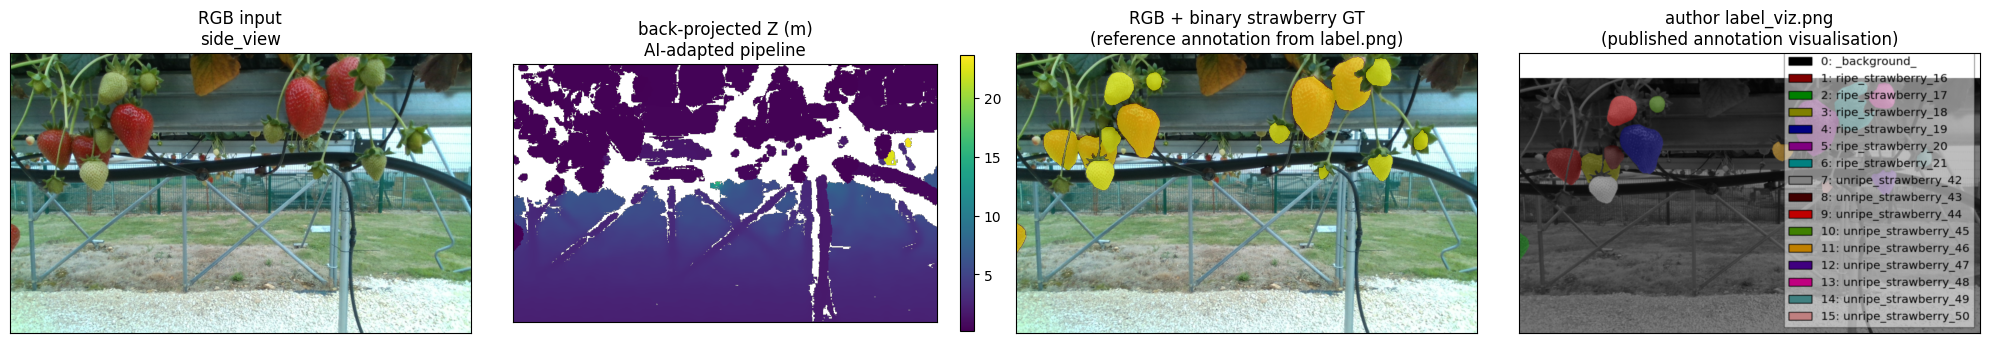

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
fig, ax = plt.subplots(1, 4, figsize=(20, 4.2))
ax[0].imshow(cap0["rgb"]); ax[0].set_title(f"RGB input\n{cap0['name']}")
d = np.where(cap0["valid"], cap0["pts"][..., 2], np.nan)
im1 = ax[1].imshow(d, cmap="viridis"); ax[1].set_title("back-projected Z (m)\nAI-adapted pipeline")
plt.colorbar(im1, ax=ax[1], fraction=0.03)
ax[2].imshow(cap0["rgb"]); ax[2].imshow(np.ma.masked_where(cap0["gt"] == 0, cap0["gt"]),
                                        cmap="autumn_r", alpha=0.55)
ax[2].set_title("RGB + binary strawberry GT\n(reference annotation from label.png)")
viz = Image.open(os.path.join(caps[0], "label_viz.png")).resize((871, 530))
ax[3].imshow(viz); ax[3].set_title("author label_viz.png\n(published annotation visualisation)")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.savefig("/content/fig_input_preview.png", bbox_inches="tight")
plt.show()

## 7. Dataset and loaders

A ported loader replaces `dataset_class.Loading_dataset` (author file imports
`data as data_utils` and `scipy.misc`, both unavailable/broken in modern environments,
and the simulated `pointclouds/*.ply` + `binary/*.npy` layout does not exist in the
public archive). The port keeps the author's interface: organised 871×871 zero-padded
grids of `pts`, `normals`, `gt`. The author's random Z-rotation + shift augmentation
(`dataset_class.py:71-91`, kept for the simulated pipeline) is **disabled** here:
its coordinate-shift behaviour is unvalidated on real captures; disabling it is a
labeled adaptation that makes this reduced run deterministic.

**データローダ（JA）：** 著者loaderのインターフェースを維持した移植版です。実データ用の
前処理が未公開のため、学習時の回転+平行移動拡張は無効化（明示的な適応）し、決定的な
動作にしています。

In [ ]:
import torch, numpy as np

class StereoGridDataset(torch.utils.data.Dataset):
    # Port of dataset_class.Loading_dataset for the real stereo captures.
    # Author interface kept: 871x871 zero-padded organised grids; sample dict keys
    # 'pts','normals','gt' (names 'colors' dropped: not consumed by CNN3D pts+normals input).
    def __init__(self, cap_paths, training=False):
        self.caps = cap_paths
        self.training = training  # author augmentation disabled for real data (see above)
        self.width, self.height = 530, 871  # dataset_class.py naming: height=871 grid width
    def __len__(self): return len(self.caps)
    def __getitem__(self, index):
        c = load_capture(self.caps[index])  # parses on demand (dataset bytes stay in Colab)
        pts = np.zeros((871, 871, 3), np.float32)
        nrm = np.zeros((871, 871, 3), np.float32)
        gt = np.zeros((871, 871), np.uint8)
        pts[:530, :871] = c["pts"]; nrm[:530, :871] = c["nrm"]; gt[:530, :871] = c["gt"]
        return {"pts": torch.from_numpy(pts), "normals": torch.from_numpy(nrm),
                "gt": torch.from_numpy(gt), "names": c["name"]}

# deterministic split: sorted captures -> first 24 train, last 8 held out
caps_sorted = sorted(caps)
N_TRAIN, N_EVAL = 24, 8
train_caps, eval_caps = caps_sorted[:N_TRAIN], caps_sorted[-N_EVAL:]
assert not (set(train_caps) & set(eval_caps))
train_ds = StereoGridDataset(train_caps, training=True)
eval_ds = StereoGridDataset(eval_caps, training=False)
print(f"train clouds: {len(train_ds)} | held-out clouds: {len(eval_ds)} (of {len(caps_sorted)} captures)")

train clouds: 24 | held-out clouds: 8 (of 64 captures)


DataLoaders follow `train.py`/`test.py`: shuffled batched training, unshuffled
batch-size-1 evaluation.

**DataLoader（JA）：** train.py/test.pyに従い、学習はshuffle+batch、評価はbatch 1です。

In [ ]:
BATCH = 2  # author uses 4; T4 measured peak 13.4 GiB at batch 4 vs 12.3 GiB at batch 2
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
eval_dl = torch.utils.data.DataLoader(eval_ds, batch_size=1, shuffle=False, num_workers=1)
s = next(iter(train_dl))
print("batch pts:", tuple(s["pts"].shape), "| gt:", tuple(s["gt"].shape),
      "| dtype:", s["pts"].dtype, s["gt"].dtype)

batch pts: (2, 871, 871, 3) | gt: (2, 871, 871) | dtype: torch.float32 torch.uint8


## 8. CNN3D — pinned author architecture with two labeled adaptations

The class below is the author's `CNN3D(input_channels, output_channels)`
(`com_elec_agri/CNN3D.py` @ `682e5d8`) with exactly two changes:

1. **torchvision weights API** — `vgg16(pretrained=True)` is replaced by
   `vgg16(weights=VGG16_Weights.IMAGENET1K_V1)` (same checkpoint, current API).
2. **Shape-checked VGG16 init** — the author's `init_vgg_weigts` assigns the 3-input-channel
   VGG16 first-layer weight to the 6-input-channel `encoder_conv_00` via a raw `.data`
   rebind. Probed on this runtime: the rebind succeeds but the subsequent forward pass
   **fails** ("expected input to have 3 channels"). We therefore copy VGG16 weights only
   into shape-matching encoder convs; the 6-channel first conv keeps its default init.

Everything else (layer sizes, BatchNorm, max-unpool decoder, skip adds, forward) is the
author's code. **AI-generated glue is limited to the two items above.**

**モデル（JA）：** 著者のCNN3Dそのものに、torchvision API対応と初期化の形状チェック
（実測で著者の初期化は現行PyTorchではforward不能なため）の2点の変更を加えたものです。

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, torchvision.models as models

class CNN3D(nn.Module):
    # Adapted from lelouedec/PhD_3DPerception@682e5d8 com_elec_agri/CNN3D.py.
    def __init__(self, input_channels, output_channels):
        super(CNN3D, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)  # adaptation 1
        self.encoder_conv_00 = nn.Sequential(nn.Conv2d(input_channels,64,3,padding=1),nn.BatchNorm2d(64))
        self.encoder_conv_01 = nn.Sequential(nn.Conv2d(64,64,3,padding=1),nn.BatchNorm2d(64))
        self.encoder_conv_10 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128))
        self.encoder_conv_11 = nn.Sequential(nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128))
        self.encoder_conv_20 = nn.Sequential(nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256))
        self.encoder_conv_21 = nn.Sequential(nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256))
        self.encoder_conv_22 = nn.Sequential(nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256))
        self.encoder_conv_30 = nn.Sequential(nn.Conv2d(256,512,3,padding=1),nn.BatchNorm2d(512))
        self.encoder_conv_31 = nn.Sequential(nn.Conv2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.encoder_conv_32 = nn.Sequential(nn.Conv2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.encoder_conv_40 = nn.Sequential(nn.Conv2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.encoder_conv_41 = nn.Sequential(nn.Conv2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.encoder_conv_42 = nn.Sequential(nn.Conv2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.init_vgg_weights()  # adaptation 2 (see docstring)
        self.decoder_convtr_42 = nn.Sequential(nn.ConvTranspose2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.decoder_convtr_41 = nn.Sequential(nn.ConvTranspose2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.decoder_convtr_40 = nn.Sequential(nn.ConvTranspose2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.decoder_convtr_32 = nn.Sequential(nn.ConvTranspose2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.decoder_convtr_31 = nn.Sequential(nn.ConvTranspose2d(512,512,3,padding=1),nn.BatchNorm2d(512))
        self.decoder_convtr_30 = nn.Sequential(nn.ConvTranspose2d(512,256,3,padding=1),nn.BatchNorm2d(256))
        self.decoder_convtr_22 = nn.Sequential(nn.ConvTranspose2d(256,256,3,padding=1),nn.BatchNorm2d(256))
        self.decoder_convtr_21 = nn.Sequential(nn.ConvTranspose2d(256,256,3,padding=1),nn.BatchNorm2d(256))
        self.decoder_convtr_20 = nn.Sequential(nn.ConvTranspose2d(256,128,3,padding=1),nn.BatchNorm2d(128))
        self.decoder_convtr_11 = nn.Sequential(nn.ConvTranspose2d(128,128,3,padding=1),nn.BatchNorm2d(128))
        self.decoder_convtr_10 = nn.Sequential(nn.ConvTranspose2d(128,64,3,padding=1),nn.BatchNorm2d(64))
        self.decoder_convtr_01 = nn.Sequential(nn.ConvTranspose2d(64,64,3,padding=1),nn.BatchNorm2d(64))
        self.decoder_convtr_00 = nn.Sequential(nn.ConvTranspose2d(64,output_channels,3,padding=1))

    def forward(self, input_img):
        # author forward, verbatim structure: 5-stage encoder, max-unpool decoder, skip adds
        dim_0 = input_img.size()
        x_00 = F.relu(self.encoder_conv_00(input_img))
        x_01 = F.relu(self.encoder_conv_01(x_00))
        x_0, indices_0 = F.max_pool2d(x_01, 2, 2, return_indices=True)
        dim_1 = x_0.size()
        x_10 = F.relu(self.encoder_conv_10(x_0))
        x_11 = F.relu(self.encoder_conv_11(x_10))
        x_1, indices_1 = F.max_pool2d(x_11, 2, 2, return_indices=True)
        dim_2 = x_1.size()
        x_20 = F.relu(self.encoder_conv_20(x_1))
        x_21 = F.relu(self.encoder_conv_21(x_20))
        x_22 = F.relu(self.encoder_conv_22(x_21))
        x_2, indices_2 = F.max_pool2d(x_22, 2, 2, return_indices=True)
        dim_3 = x_2.size()
        x_30 = F.relu(self.encoder_conv_30(x_2))
        x_31 = F.relu(self.encoder_conv_31(x_30))
        x_32 = F.relu(self.encoder_conv_32(x_31))
        x_3, indices_3 = F.max_pool2d(x_32, 2, 2, return_indices=True)
        dim_4 = x_3.size()
        x_40 = F.relu(self.encoder_conv_40(x_3))
        x_41 = F.relu(self.encoder_conv_41(x_40))
        x_42 = F.relu(self.encoder_conv_42(x_41))
        x_4, indices_4 = F.max_pool2d(x_42, 2, 2, return_indices=True)
        x_4d = F.max_unpool2d(x_4, indices_4, 2, 2, output_size=dim_4)
        x_42d = F.relu(self.decoder_convtr_42(x_4d))
        x_41d = F.relu(self.decoder_convtr_41(x_42d))
        x_40d = F.relu(self.decoder_convtr_40(x_41d))
        x_40d = x_40d + x_3
        x_3d = F.max_unpool2d(x_40d, indices_3, 2, 2, output_size=dim_3)
        x_32d = F.relu(self.decoder_convtr_32(x_3d))
        x_31d = F.relu(self.decoder_convtr_31(x_32d))
        x_30d = F.relu(self.decoder_convtr_30(x_31d))
        x_30d = x_30d + x_2
        x_2d = F.max_unpool2d(x_30d, indices_2, 2, 2, output_size=dim_2)
        x_22d = F.relu(self.decoder_convtr_22(x_2d))
        x_21d = F.relu(self.decoder_convtr_21(x_22d))
        x_20d = F.relu(self.decoder_convtr_20(x_21d))
        x_20d = x_20d + x_1
        x_1d = F.max_unpool2d(x_20d, indices_1, 2, 2, output_size=dim_1)
        x_11d = F.relu(self.decoder_convtr_11(x_1d))
        x_10d = F.relu(self.decoder_convtr_10(x_11d))
        x_10d = x_10d + x_0
        x_0d = F.max_unpool2d(x_10d, indices_0, 2, 2, output_size=dim_0)
        x_01d = F.relu(self.decoder_convtr_01(x_0d))
        x_00d = self.decoder_convtr_00(x_01d)
        return x_00d

    def init_vgg_weights(self):
        # Adaptation 2 of author init_vgg_weigts(): the author rebinds .data across a
        # 3->6 input-channel mismatch on encoder_conv_00 (CNN3D.py:134-135); probed on
        # this runtime that breaks the forward pass. Copy only shape-matching weights.
        pairs = [(self.encoder_conv_00, self.vgg16.features[0]),
                 (self.encoder_conv_01, self.vgg16.features[2]),
                 (self.encoder_conv_10, self.vgg16.features[5]),
                 (self.encoder_conv_11, self.vgg16.features[7]),
                 (self.encoder_conv_20, self.vgg16.features[10]),
                 (self.encoder_conv_21, self.vgg16.features[12]),
                 (self.encoder_conv_22, self.vgg16.features[14]),
                 (self.encoder_conv_30, self.vgg16.features[17]),
                 (self.encoder_conv_31, self.vgg16.features[19]),
                 (self.encoder_conv_32, self.vgg16.features[21]),
                 (self.encoder_conv_40, self.vgg16.features[24]),
                 (self.encoder_conv_41, self.vgg16.features[26]),
                 (self.encoder_conv_42, self.vgg16.features[28])]
        copied = 0
        for dst, src in pairs:
            if dst[0].weight.shape == src.weight.shape:
                dst[0].weight.data.copy_(src.weight.data)
                dst[0].bias.data.copy_(src.bias.data)
                copied += 1
        print(f"VGG16 init: copied {copied}/13 encoder convs (shape-matching only; "
              f"6-ch first conv keeps default init)")

## 9. Training setup — author hyperparameters

Exactly as `train.py`: `Adam(lr=1e-5)`, `CrossEntropyLoss(weight=[1,16])`, input =
`cat(pts, normals)` (6 channels), 2 output classes, `.train()` on CUDA. Deviations,
all labeled: **batch 2** (T4 memory headroom; author uses 4), **40 epochs** (reduced
budget; author: 500), **24 training clouds** (deterministic subset; the author trains
on the full simulated split). A fixed seed makes the run reproducible.

**学習設定（JA）：** 著者のハイパーパラメータ（Adam lr=1e-5、重み付きCE [1,16]）をそのまま
使用し、バッチ2・40エポック・24クラウドに削減したことを明示しています。

In [ ]:
import torch, torch.nn as nn, numpy as np, time
torch.manual_seed(0); np.random.seed(0)
model = CNN3D(input_channels=6, output_channels=2).train().to(device)  # train.py:11
lr = 1e-5          # train.py:14
EPOCHS = 40        # reduced budget (author: 500)
optimizer = torch.optim.Adam([{'params': model.parameters(), 'lr': lr}])  # train.py:17
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1,16]).float()).to(device)  # train.py:18
print("params (M):", round(sum(p.numel() for p in model.parameters())/1e6, 2))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


  0%|          | 0.00/528M [00:00<?, ?B/s]

  0%|          | 1.62M/528M [00:00<00:32, 16.8MB/s]

  4%|▎         | 19.8M/528M [00:00<00:04, 118MB/s] 

  8%|▊         | 40.4M/528M [00:00<00:03, 162MB/s]

...

 95%|█████████▍| 500M/528M [00:05<00:00, 100MB/s] 

 98%|█████████▊| 516M/528M [00:05<00:00, 113MB/s]

100%|██████████| 528M/528M [00:05<00:00, 104MB/s]

VGG16 init: copied 12/13 encoder convs (shape-matching only; 6-ch first conv keeps default init)


params (M): 167.8


**Training loop** — the author's loop structure (`train.py:27-52`): per-batch
`cat(pts, normals) → model → weighted CE → backward → step`, loss averaged per epoch.
Wall time per epoch is printed; expect ≈ 30–45 s/epoch on T4 (measured 1230 ms/step at
batch 2 plus augmentation-free loading).

**学習ループ（JA）：** 著者のtrain.pyと同一構造です。T4で約30–45秒/エポックを見込みます。

In [ ]:
import time
torch.backends.cudnn.benchmark = True
loss_history = []
t_start = time.time()
for epoch in range(EPOCHS):
    model.train()
    losses = []
    for sample in train_dl:  # train.py:29-50 structure
        pts_tensor = sample['pts'].float().permute(0, 3, 1, 2)
        normals_tensor = sample['normals'].float().permute(0, 3, 1, 2)
        target_tensor = sample['gt'].to(device=device, dtype=torch.long)
        input_tensor = torch.cat([pts_tensor, normals_tensor], 1).to(device="cuda", dtype=torch.float32)
        out = model(input_tensor)
        loss = criterion(out, target_tensor)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.float().cpu().detach().numpy().mean())
        del loss, input_tensor, out, target_tensor
    loss_history.append(float(np.mean(losses)))
    print(f"epoch {epoch+1}/{EPOCHS}  loss {loss_history[-1]:.4f}  "
          f"elapsed {int(time.time()-t_start)}s", flush=True)
torch.save(model.state_dict(), "/content/cnn3d_reduced_stereo.ckpt")
print(f"training done in {int(time.time()-t_start)}s")

epoch 1/40  loss 1.1433  elapsed 130s


epoch 2/40  loss 1.0324  elapsed 159s


epoch 3/40  loss 0.9566  elapsed 187s


epoch 4/40  loss 0.8892  elapsed 215s


epoch 5/40  loss 0.8374  elapsed 244s


...

epoch 37/40  loss 0.1252  elapsed 1156s


epoch 38/40  loss 0.1181  elapsed 1185s


epoch 39/40  loss 0.1119  elapsed 1213s


epoch 40/40  loss 0.1127  elapsed 1242s


training done in 1249s


## 10. Evaluation — the author's exact protocol (`test.py` @ `682e5d8`)

Verbatim procedure: threshold the **raw channel-1 logits** (the author applies no
softmax) at `eth = 0.50 … 0.90` step 0.05; flatten predictions/GT and keep only
non-padded, valid points (`pts != 0`); compute per-cloud metrics with the author's
`metrics.py` (`Accuracy`, `Kappa_cohen`, `precision_recall`) and inline IoU; collect the
precision–recall curve points and AUC (`sklearn.metrics.auc`), as in `test.py:15-96`.
Metrics are averaged over the 8 held-out clouds at each threshold. Note the author's
`Kappa_cohen`/`Accuracy` divide by `groundtruth.shape[0]`, which is the point count
after flattening.

**評価（JA）：** 著者test.pyのプロトコル（生ロジットへの閾値適用、有効点マスク、
作者のmetrics.py、PR曲線からのAUC）をそのまま実行します。

In [ ]:
import numpy as np, torch
from sklearn import metrics as skmetrics

precisions, recalls = [0.0], [1.0]  # test.py:24-25
sweep = []  # (eth, acc, kappa, iou, precision, recall)
eth = 0.5
while eth < 0.95:  # test.py:26
    accs = kappas = ious = precs = recs = 0.0
    idfix = 0
    for sample in eval_dl:
        pts_tensor = sample['pts'].float().permute(0, 3, 1, 2)
        normals_tensor = sample['normals'].float().permute(0, 3, 1, 2)
        target_tensor = sample['gt'].to(device="cuda", dtype=torch.long)
        input_tensor = torch.cat([pts_tensor, normals_tensor], 1).cuda()  # test.py:40
        with torch.no_grad():
            out = model(input_tensor)
        softmax_mx = out.detach().permute(0, 2, 3, 1).cpu().numpy()[0]  # test.py:48
        softmax_mx[softmax_mx[:, :, 1] < eth] = 0.0   # test.py:50-51 (raw logits, author behaviour)
        softmax_mx[softmax_mx[:, :, 1] != 0.0] = 1.0
        pts = pts_tensor.detach().permute(0, 2, 3, 1).numpy()[0]
        pts2 = pts.reshape((pts.shape[0] * pts.shape[1], 3))
        idxs = np.any(pts2 != [0.0, 0.0, 0.0], axis=-1)  # test.py:55 valid (non-padded) points
        pred = softmax_mx[:, :, 1].reshape(-1)[idxs]
        gta = target_tensor.cpu().numpy()[0].reshape(-1)[idxs]
        union = np.logical_or(pred, gta); inter = np.logical_and(pred, gta)
        iou = inter.sum() / union.sum()  # test.py:64-66
        ious += iou
        kappas += metrics.Kappa_cohen(pred, gta)   # author metrics.py, verbatim
        accs += metrics.Accuracy(pred, gta)
        something = metrics.precision_recall(pred, gta)
        precs += something[0]; recs += something[1]
        idfix += 1
    accs /= idfix; kappas /= idfix; ious /= idfix; precs /= idfix; recs /= idfix
    precisions.append(precs); recalls.append(recs)  # test.py:80-81
    sweep.append((eth, accs, kappas, ious, precs, recs))
    print(f"eth {eth:.2f}  acc {accs:.4f}  kappa {kappas:.4f}  iou {ious:.4f}  prec {precs:.4f}  rec {recs:.4f}", flush=True)
    eth += 0.05
precisions.append(1.0); recalls.append(0.0)  # test.py:84-85
AUC = skmetrics.auc(np.array(recalls), np.array(precisions))  # test.py:89
print("AUC (author PR-point protocol):", round(AUC, 4))

eth 0.50  acc 0.9031  kappa 0.4253  iou 0.2404  prec 0.2933  rec 0.5951


eth 0.55  acc 0.9063  kappa 0.4322  iou 0.2432  prec 0.3000  rec 0.5857


eth 0.60  acc 0.9092  kappa 0.4387  iou 0.2459  prec 0.3067  rec 0.5767


eth 0.65  acc 0.9119  kappa 0.4452  iou 0.2484  prec 0.3134  rec 0.5677


eth 0.70  acc 0.9145  kappa 0.4512  iou 0.2506  prec 0.3199  rec 0.5585


eth 0.75  acc 0.9170  kappa 0.4573  iou 0.2530  prec 0.3268  rec 0.5502


eth 0.80  acc 0.9193  kappa 0.4631  iou 0.2549  prec 0.3334  rec 0.5412


eth 0.85  acc 0.9214  kappa 0.4685  iou 0.2562  prec 0.3398  rec 0.5315


eth 0.90  acc 0.9234  kappa 0.4735  iou 0.2574  prec 0.3460  rec 0.5222


AUC (author PR-point protocol): 0.4341


**Results table and reference comparison.** We report the author's metrics at
`eth=0.50` and at the threshold with the best mean IoU, alongside the paper's Table 4
stereo reference for CNN3D (Acc 92.11%, κ 0.62, mIoU 0.42, AUC 0.62). The reference is
**literature context only**: the paper's number comes from full training on the
complete stereo split, not this reduced run. Results are exported to CSV inside Colab.

**結果表（JA）：** 著者指標をeth=0.50と最良IoU閾値で示し、論文Table 4のstereo参照値は
あくまで文献参照として併記します（削減予算のため再現値ではありません）。CSVはColab内に
保存されます。

In [ ]:
import pandas as pd
best = max(sweep, key=lambda r: r[3])
rows = []
for label, r in [("eth=0.50", sweep[0]), (f"best-IoU (eth={best[0]:.2f})", best)]:
    rows.append({"threshold": label, "Accuracy [%]": round(100*r[1], 2), "Cohen kappa": round(r[2], 3),
                 "mean IoU": round(r[3], 3), "precision": round(r[4], 3), "recall": round(r[5], 3)})
rows.append({"threshold": "PAPER Table 4 (stereo, CNN3D, full training)", "Accuracy [%]": 92.11,
             "Cohen kappa": 0.62, "mean IoU": 0.42, "precision": float("nan"), "recall": float("nan")})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv("/content/cnn3d_reduced_stereo_results.csv", index=False)
print("saved: /content/cnn3d_reduced_stereo_results.csv")

                                   threshold  Accuracy [%]  Cohen kappa  mean IoU  precision  recall
                                    eth=0.50         90.31        0.425     0.240      0.293   0.595
                         best-IoU (eth=0.90)         92.34        0.474     0.257      0.346   0.522
PAPER Table 4 (stereo, CNN3D, full training)         92.11        0.620     0.420        NaN     NaN
saved: /content/cnn3d_reduced_stereo_results.csv


## 11. Prediction vs reference annotation overlay

One held-out cloud is rendered as: RGB input, the reference binary annotation
(from the author's `label.png`), and the model prediction at the best-IoU threshold.
This is a single qualitative example from the reduced-budget run.

**予測と参照アノテーションの比較（JA）：** 保持したクラウド1つについて、RGB・参照GT・
予測を並べて表示します（削減予算ランでの定性例です）。

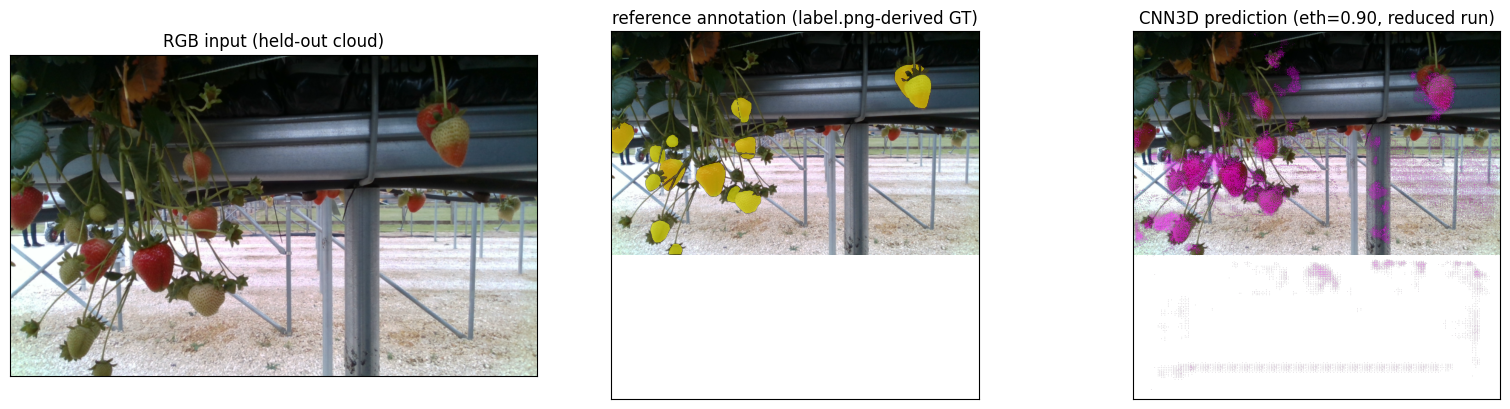

In [ ]:
import matplotlib.pyplot as plt, numpy as np, torch
model.eval()
sample = eval_ds[0]
with torch.no_grad():
    inp = torch.cat([sample['pts'].permute(2, 0, 1)[None].float(),
                     sample['normals'].permute(2, 0, 1)[None].float()], 1).cuda()
    logits = model(inp)[0].cpu().numpy()
pred = (logits[1] >= best[0]).astype(np.uint8)
gt = sample['gt'].numpy()
rgb = load_capture(eval_caps[0])["rgb"]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].imshow(rgb); ax[0].set_title("RGB input (held-out cloud)")
ax[1].imshow(rgb); ax[1].imshow(np.ma.masked_where(gt == 0, gt), cmap="autumn_r", alpha=0.55)
ax[1].set_title("reference annotation (label.png-derived GT)")
ax[2].imshow(rgb); ax[2].imshow(np.ma.masked_where(pred == 0, pred), cmap="cool_r", alpha=0.55)
ax[2].set_title(f"CNN3D prediction (eth={best[0]:.2f}, reduced run)")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.savefig("/content/fig_pred_vs_gt.png", bbox_inches="tight")
plt.show()

## 12. Per-cloud inference timing

The paper reports ≈22 ms per cloud on a GTX 1080 Ti (§5). We time `model.eval()`
forward passes at the same 871×871 padded resolution on this runtime.

**推論時間（JA）：** 論文はGTX 1080 Tiで約22 ms/クラウドと報告しています。同一解像度で
本ランタイムの実測値を示します。

In [ ]:
import time, torch
model.eval()
inp = torch.cat([eval_ds[0]['pts'].permute(2, 0, 1)[None].float(),
                 eval_ds[0]['normals'].permute(2, 0, 1)[None].float()], 1).cuda()
with torch.no_grad():
    _ = model(inp)  # warmup
    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(10):
        _ = model(inp)
    torch.cuda.synchronize()
    dt = (time.time() - t0) / 10
print(f"inference per cloud (871x871x6 input): {dt*1000:.1f} ms  (paper: ~22 ms on GTX 1080 Ti)")

inference per cloud (871x871x6 input): 356.5 ms  (paper: ~22 ms on GTX 1080 Ti)


## 13. Interpretation, limitations, and references

**What was executed (EN).** On a fresh T4 runtime: the author's pinned CNN3D was built
(two labeled adaptations), trained for a reduced budget on 24 real stereo clouds with
the author's loss/optimizer, and evaluated on 8 held-out clouds with the author's
verbatim metric code and threshold-sweep protocol; the PR-point AUC and per-cloud
inference time were measured.

**実行内容（JA）。** T4で著者CNN3D（2点の明示的適応付き）を構築し、実stereoデータ24
クラウドで削減予算学習、8クラウドで著者の評価プロトコルによる検証を行いました。

**Known limitations:**

- The paper's *simulated* dataset is not in the public archive (verified in Colab); the
  paper's Table 4/5 simulated numbers are therefore **not** reproducible from public data.
- No pretrained weights exist; the reduced-budget run (24 clouds, 40 epochs, no
  augmentation) is **expected to score well below** the paper's full-training results —
  the Table 4 row above is context, not a reproduced result.
- Real-data preprocessing (intrinsics parsing, depth back-projection, gradient normals,
  resampling to the author's grid) is an **AI-assisted adaptation**; the author's
  real-data pipeline is unpublished. Depth scale (mm) was plausibility-checked, not
  author-documented.
- The author's threshold protocol applies the threshold to raw channel-1 logits
  (no softmax) — preserved verbatim; this is the author's `test.py` behaviour.
- The author's Kappa/Accuracy divide by the flattened point count (author code
  behaviour, preserved).
- Single reduced run; no dataset-level claims. No LICENSE is present in the author
  repository — code is used here for research/reproduction citation only.

**References**

- Le Louëdec, J., Cielniak, G. (2021). 3D shape sensing and deep learning-based
  segmentation of strawberries. *Computers and Electronics in Agriculture* 190, 106374.
  [arXiv:2111.13663](https://arxiv.org/abs/2111.13663)
- Author code: https://github.com/lelouedec/PhD_3DPerception @ `682e5d8` (CNN3D.py,
  train.py, test.py, metrics.py; SHA-256 verified in this notebook).
- Data: author-linked Drive archive (`1jjtf6JcuxZQbykpApIcyl5-grX4sRWxv`), real stereo
  captures; annotations from the author's `label.png`/`label_names.txt`.